In [1]:
## 1. Cargar los datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve().parent
DATA_PATH = ROOT / "data_raw"

print("Directorio actual:", ROOT)
print("Ruta de datos:", DATA_PATH)

Directorio actual: C:\Users\erika\OneDrive\Escritorio\DAFT2026\Data Analitycs\SEMANA5\Projecto-2-Vanguard-ab-test
Ruta de datos: C:\Users\erika\OneDrive\Escritorio\DAFT2026\Data Analitycs\SEMANA5\Projecto-2-Vanguard-ab-test\data_raw


In [3]:
# Cargar datos limpios
df_demo       = pd.read_csv(DATA_PATH / "df_demo_clean.csv")
df_experiment = pd.read_csv(DATA_PATH / "df_experiment_clean.csv")
df_web        = pd.read_csv(DATA_PATH / "df_web_clean.csv")

print("Datos cargados correctamente!")
print("df_demo:      ", len(df_demo), "filas")
print("df_experiment:", len(df_experiment), "filas")
print("df_web:       ", len(df_web), "filas")

Datos cargados correctamente!
df_demo:       70591 filas
df_experiment: 50500 filas
df_web:        744641 filas


## 2. Análisis de clientes.
¿Quiénes son los clientes principales? ¿Son jóvenes o mayores?
-Empezamos analizando la distribución de edades:

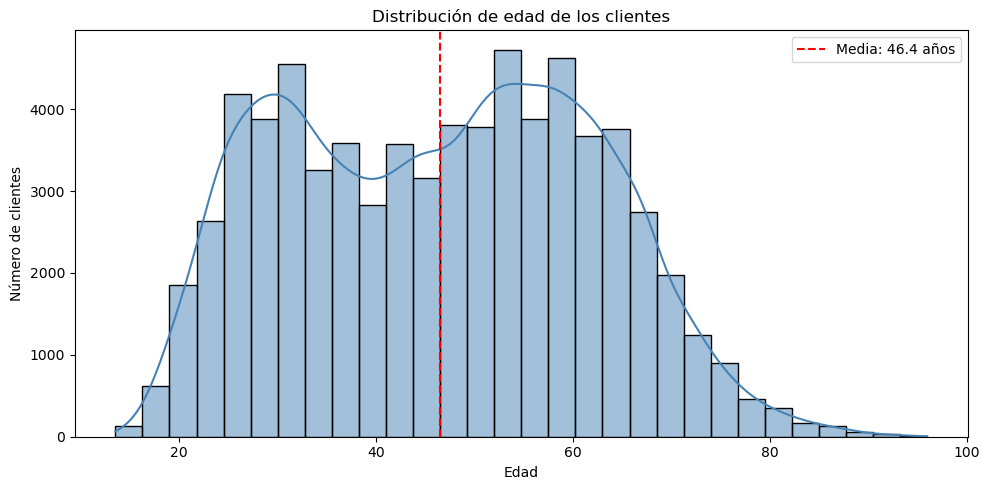

Edad media: 46.4
Edad mediana: 47.0
Edad mínima: 13.5
Edad máxima: 96.0


In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df_demo["clnt_age"], bins=30, kde=True, color="steelblue")
plt.title("Distribución de edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")
plt.axvline(df_demo["clnt_age"].mean(), color="red", linestyle="--", label=f'Media: {df_demo["clnt_age"].mean():.1f} años')
plt.legend()
plt.tight_layout()
plt.show()

print("Edad media:", round(df_demo["clnt_age"].mean(), 1))
print("Edad mediana:", round(df_demo["clnt_age"].median(), 1))
print("Edad mínima:", df_demo["clnt_age"].min())
print("Edad máxima:", df_demo["clnt_age"].max())

Conclusión:
- La edad media es de 46.4 años y la mediana es de 47 años. Como son muy parecidas, indica que tratamos con adultos de mediana edad.
- El gráfico muestra dos grupos diferenciados: Gente joven entre los 25-30 años y gente adulta de 55-60 años. Esto puede decirnos que hay dos tipos de clientes muy distintos entre sí.
- Aunque hay dos grupos diferenciados, parece que la gente adulta supera a los jovenes en cantidad.

- Analizamos la antigüedad:

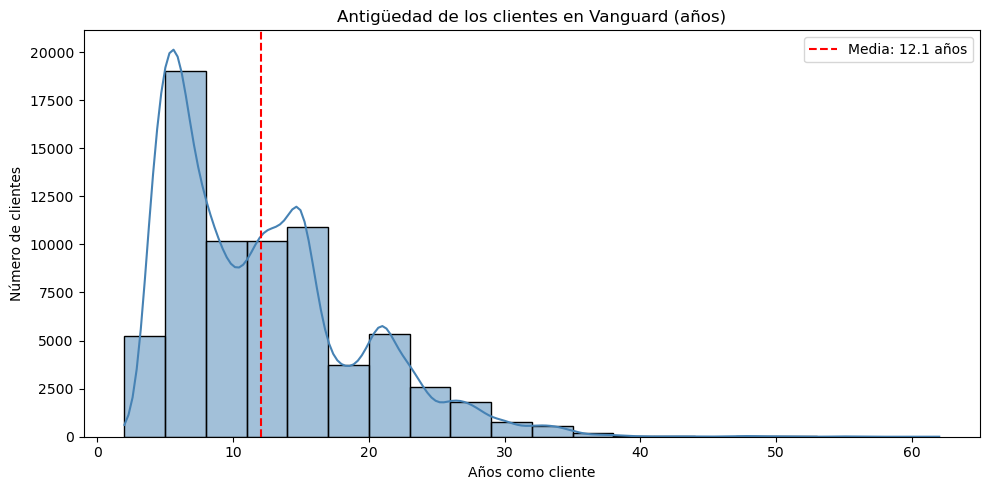

Antigüedad media: 12.1 años
Antigüedad mediana: 11.0 años
Mínimo: 2.0 años
Máximo: 62.0 años


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df_demo["clnt_tenure_yr"], bins=20, kde=True, color="steelblue")
plt.title("Antigüedad de los clientes en Vanguard (años)")
plt.xlabel("Años como cliente")
plt.ylabel("Número de clientes")
plt.axvline(df_demo["clnt_tenure_yr"].mean(), color="red", linestyle="--", label=f'Media: {df_demo["clnt_tenure_yr"].mean():.1f} años')
plt.legend()
plt.tight_layout()
plt.show()

print("Antigüedad media:", round(df_demo["clnt_tenure_yr"].mean(), 1), "años")
print("Antigüedad mediana:", round(df_demo["clnt_tenure_yr"].median(), 1), "años")
print("Mínimo:", df_demo["clnt_tenure_yr"].min(), "años")
print("Máximo:", df_demo["clnt_tenure_yr"].max(), "años")

Conclusiones:
- La mayoría de clientes tienen entre 5-7 años aproximádamente de antigüedad
- La media es de 12.1 años, lo que indica que no son clientes nuevos.
- Hay muy pocos clientes que llegan a más de 30 años de antigüedad, lo que quiere decir es que Vanguard tiene una base de clientes fiel y establecida.

Analisis de Relación entre edad y antigüedad

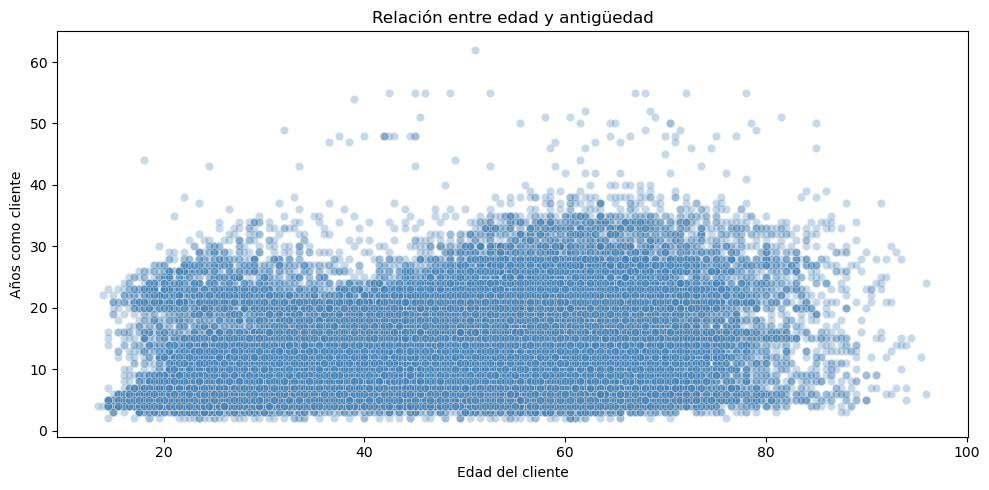

Correlación entre edad y antigüedad: 0.309


In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_demo, x="clnt_age", y="clnt_tenure_yr", alpha=0.3, color="steelblue")
plt.title("Relación entre edad y antigüedad")
plt.xlabel("Edad del cliente")
plt.ylabel("Años como cliente")
plt.tight_layout()
plt.show()

print("Correlación entre edad y antigüedad:", round(df_demo["clnt_age"].corr(df_demo["clnt_tenure_yr"]), 3))

Conclusiones:
- La correlación entre edad y antigüedad es de 0.309.
- Los clientes más jóvenes tienen necesariamente menos antigüedad.
- A partir de los 40-50 años hay mucha dispersión, lo que indica que Vanguard capta clientes de mediana edad tanto nuevos como establecidos.

Análisis de balance de cuentas

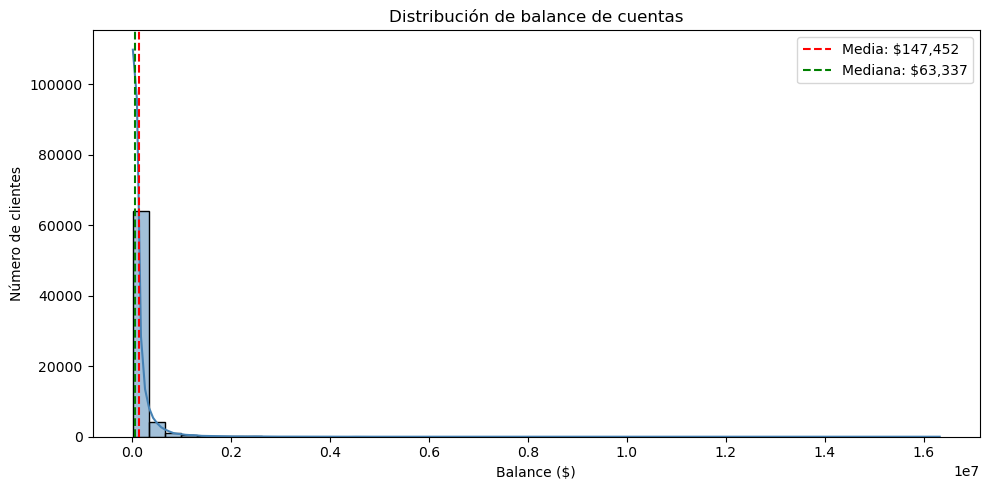

Balance medio:  $ 147451.82
Balance mediana: $ 63336.89
Balance mínimo: $ 13789.42
Balance máximo: $ 16320040.15


In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_demo["bal"], bins=50, kde=True, color="steelblue")
plt.title("Distribución de balance de cuentas")
plt.xlabel("Balance ($)")
plt.ylabel("Número de clientes")
plt.axvline(df_demo["bal"].mean(), color="red", linestyle="--", label=f'Media: ${df_demo["bal"].mean():,.0f}')
plt.axvline(df_demo["bal"].median(), color="green", linestyle="--", label=f'Mediana: ${df_demo["bal"].median():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print("Balance medio:  $", round(df_demo["bal"].mean(), 2))
print("Balance mediana: $", round(df_demo["bal"].median(), 2))
print("Balance mínimo: $", round(df_demo["bal"].min(), 2))
print("Balance máximo: $", round(df_demo["bal"].max(), 2))

Conclusiones:
- La distribución del balance está muy sesgada a la derecha — la mayoría 
  de clientes tienen balances bajos pero hay unos pocos con balances muy altos.
- La mediana ($63,337) es más representativa que la media ($147,452) 
  porque no se ve afectada por los valores extremos.
- El balance mínimo es $13,789 y el máximo $16,320,040 — hay una 
  diferencia enorme entre clientes.

Análisis demográfico por grupo (Test vs Control)

In [9]:
# Unir df_demo con df_experiment
df_demo_exp = df_demo.merge(df_experiment, on="client_id", how="inner")

print("Filas tras unir:", len(df_demo_exp))
print()
print("Distribución Test vs Control:")
print(df_demo_exp["Variation"].value_counts())

Filas tras unir: 50485

Distribución Test vs Control:
Variation
Test       26959
Control    23526
Name: count, dtype: int64


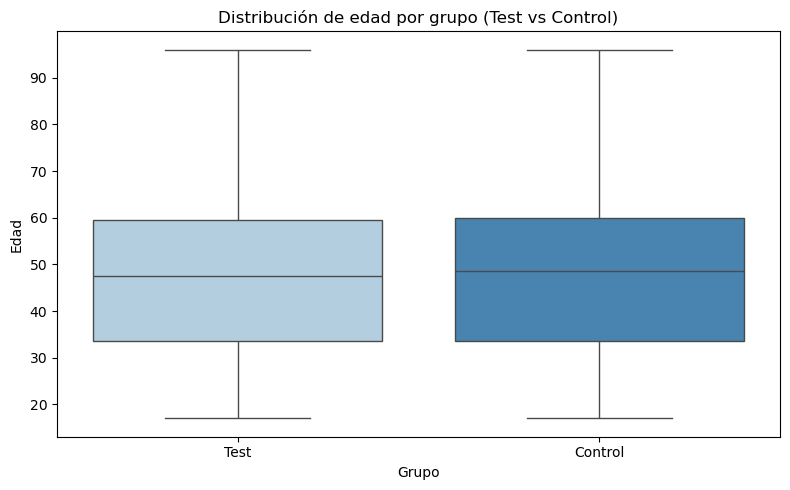

Edad media por grupo:
Variation
Control    47.5
Test       47.2
Name: clnt_age, dtype: float64


In [10]:
# Edad media por grupo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_demo_exp, x="Variation", y="clnt_age", hue="Variation", legend=False, palette="Blues")
plt.title("Distribución de edad por grupo (Test vs Control)")
plt.xlabel("Grupo")
plt.ylabel("Edad")
plt.tight_layout()
plt.show()

print("Edad media por grupo:")
print(df_demo_exp.groupby("Variation")["clnt_age"].mean().round(1))

Conclusiones:
- La distribución de edad es muy similar entre Test y Control.
- La mediana de ambos grupos está alrededor de los 48-49 años.
- Esto es una buena señal porque indica que los dos grupos están bien 
  equilibrados en edad, lo que valida el experimento.

Ahora comparamos la  antigüedad entre los dos grupos:

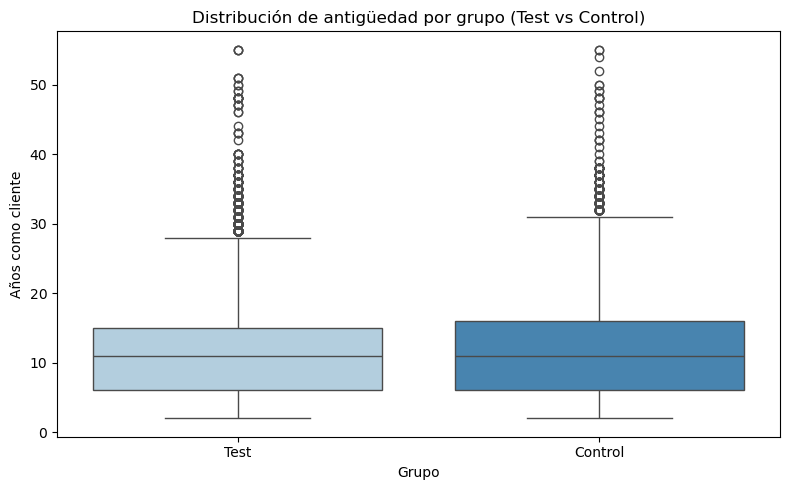

Antigüedad media por grupo:
Variation
Control    12.1
Test       12.0
Name: clnt_tenure_yr, dtype: float64


In [11]:
# Antigüedad media por grupo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_demo_exp, x="Variation", y="clnt_tenure_yr", hue="Variation", legend=False, palette="Blues")
plt.title("Distribución de antigüedad por grupo (Test vs Control)")
plt.xlabel("Grupo")
plt.ylabel("Años como cliente")
plt.tight_layout()
plt.show()

print("Antigüedad media por grupo:")
print(df_demo_exp.groupby("Variation")["clnt_tenure_yr"].mean().round(1))

Conclusiones:
- La antigüedad media es casi idéntica entre grupos: 12.1 años (Control) 
  y 12.0 años (Test).
- Los dos grupos son muy similares en antigüedad, lo que confirma que 
  el experimento está bien equilibrado.
- Hay outliers en ambos grupos pero en proporciones similares.

Análisis de Distribución de género por grupo

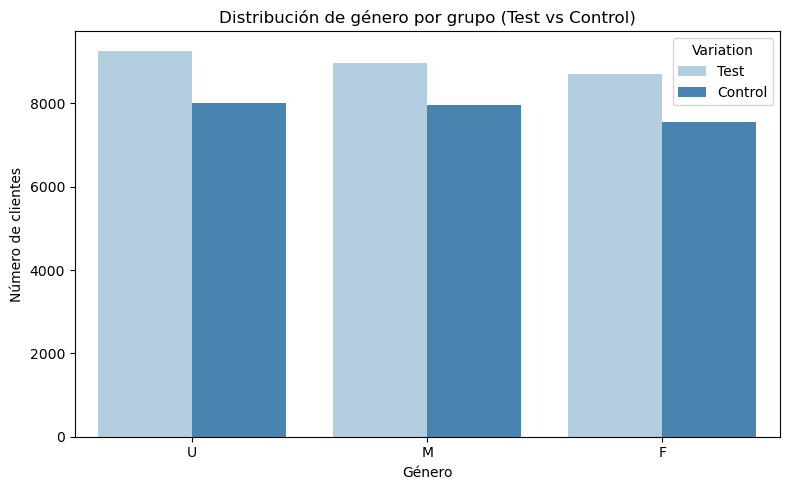

Distribución de género por grupo:
gendr         F     M     U
Variation                  
Control    7542  7970  8014
Test       8716  8977  9266


In [12]:
# Género por grupo
plt.figure(figsize=(8, 5))
sns.countplot(data=df_demo_exp, x="gendr", hue="Variation", palette="Blues")
plt.title("Distribución de género por grupo (Test vs Control)")
plt.xlabel("Género")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

print("Distribución de género por grupo:")
print(df_demo_exp.groupby(["Variation", "gendr"]).size().unstack())

Conclusiones:
- La distribución de género es proporcional entre Test y Control.
- En ambos grupos el orden es similar: U > M > F.
- El experimento está bien equilibrado en términos de género.